# **Atividade k-means C24**

Aluno: Pedro Henrique Ribeiro Dias Matrícula: 529 Curso: GES

## **Escolha de Locais para Centros de Distribuição com k-Means**

Uma empresa de logística deseja instalar centros de distribuição em uma região para atender 1000 clientes de forma eficiente. O objetivo é minimizar a distância total de transporte entre os centros e os clientes

In [58]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [59]:
# Gerar dados fictícios (1000 clientes, 2 clusters naturais)

clientes, _ = make_blobs(n_samples=1000, centers=2, cluster_std=0.8, random_state=0)

df = pd.DataFrame(clientes, columns=['latitude', 'longitude'])


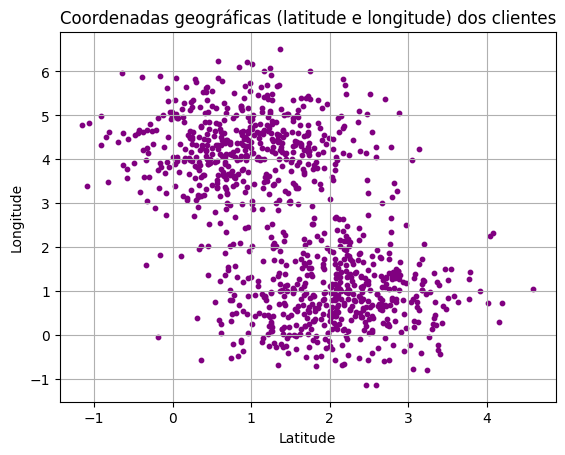

In [60]:
# Plotar clientes e centroides

plt.scatter(df['latitude'], df['longitude'], s=10, c='purple')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.title('Coordenadas geográficas (latitude e longitude) dos clientes')
plt.grid(True)
plt.show()

2. Qual é a quantidade correta de centros de distribuição para minimizar a distância entre os clientes e os centros?

OBS.: Você pode usar o método do cotovelo para descobrir a quantidade de centros de distribuição.

In [61]:
inertia = []
max_clusters = 10
seed = 42 # Padrão

for k in range(1, max_clusters+1):
  kmean = KMeans(n_clusters=k, random_state=seed)
  kmean.fit(clientes)
  inertia.append(kmean.inertia_)

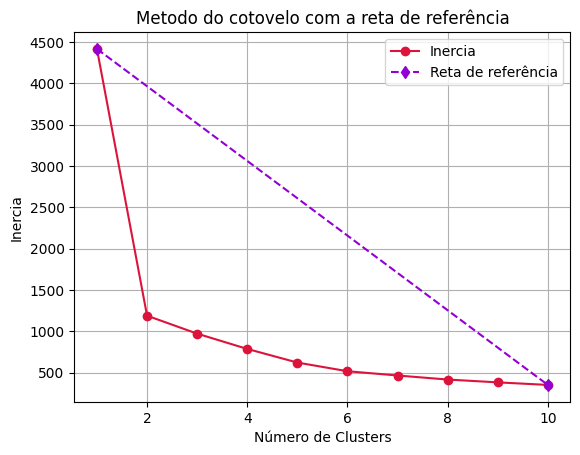

In [62]:
kvalues = range(1, max_clusters+1)

# Plot dos valores
plt.plot(kvalues, inertia, marker='o', label="Inercia", c='crimson')

# Primeiro e ultimos valores
first = (1, inertia[0])
last = (max_clusters, inertia[-1])

# Calculo e plot da reta de referencia
x = np.array([1, max_clusters])
y = np.array([inertia[0], inertia[-1]])
a, b = np.polyfit(x, y, 1)

plt.plot(x, a*x + b, marker='d', linestyle='--', label='Reta de referência', c='darkviolet')

# Dados do plot
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.title('Metodo do cotovelo com a reta de referência')
plt.legend()
plt.grid(True)
plt.show()

In [63]:
distancias = []
for k in range(1, max_clusters+1):
    y_reta = a * k + b
    distancia = abs(inertia[k-1] - y_reta)
    distancias.append(distancia)

k_ideal = np.argmax(distancias) +1
print(f"O numero ideal de clusters k: k = {k_ideal}")

O numero ideal de clusters k: k = 2


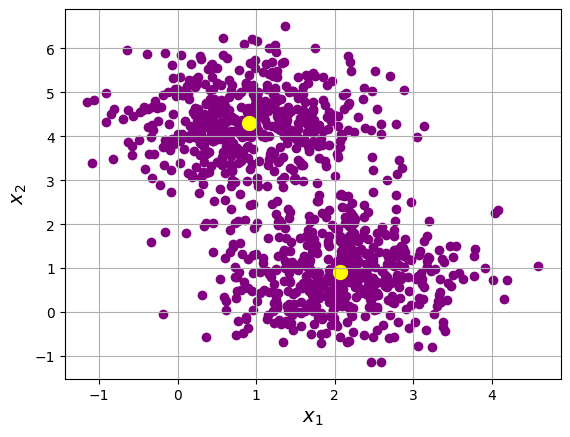

In [64]:
kmean_ideal = KMeans(n_clusters=k_ideal, random_state=seed)
kmean_ideal.fit(clientes)

plt.scatter(clientes[:,0], clientes[:,1], c='purple')
plt.scatter(kmean_ideal.cluster_centers_[:, 0], kmean_ideal.cluster_centers_[:, 1], s=100, c='yellow')
plt.xlabel('$x_1$', fontsize=14)
plt.ylabel('$x_2$', fontsize=14)
plt.grid()
plt.show()